In [153]:
#άσκηση 1η
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import IPython
import sounddevice as sd
import soundfile as sf

In [154]:
#1.1
n = np.arange(1000) #0,1,2 ... 999
omega_row = [0.5346, 0.5906, 0.6535, 0.7217]
omega_column = [0.9273, 1.0247, 1.1328]

term = []
for omega_r in omega_row:
    for omega_c in omega_column:
        term.append(np.sin(omega_r*n)+np.sin(omega_c*n))

d = [] #ψηφία
d.append(term[10]) #το ψηφίο 0
d.extend(term[0:9]) #τα υπόλοιπα

Text(0, 0.5, '|D|')

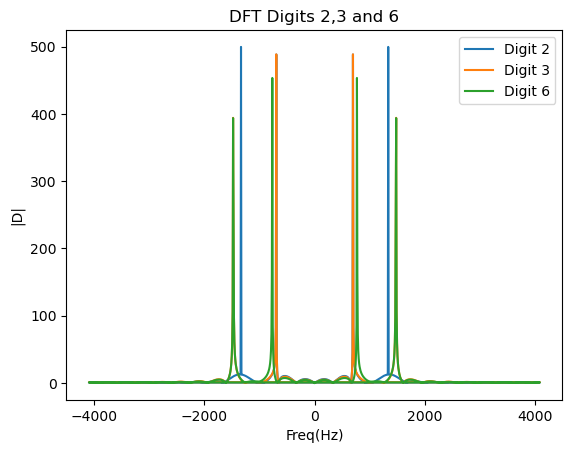

In [155]:
#1.2
f = np.fft.fftfreq(1024,1/8192) #N = 1024, fs = 8192Hz, max freq = fs/2 για να μην έχω aliasing
D2 = np.fft.fft(d[2], 1024)
D3 = np.fft.fft(d[3], 1024)
D6 = np.fft.fft(d[6], 1024)

plt.plot(f,np.abs(D2))
plt.plot(f,np.abs(D3))
plt.plot(f, np.abs(D6))

plt.title('DFT Digits 2,3 and 6')  
plt.legend(['Digit 2', 'Digit 3', 'Digit 6'])
plt.xlabel('Freq(Hz)')                        
plt.ylabel('|D|')                             

In [156]:
#1.3
AM1 = [0, 3, 1, 2, 3, 9, 0, 1] 
AM2 = [0, 3, 1, 2, 3, 0, 8, 4]

a = np.zeros(100)
data = np.concatenate(d) #σε μορφή np array, 1D vector

tone_sequence = np.concatenate([data[0:1000], a]) #στην αρχή έχουμε το μηδέν
#το tone sequence είναι 06246985, φαίνεται και από το 1.6
for idx in range(1, len(AM1)):
    tone = (AM1[idx]+AM2[idx])%10 #εύρεση tone
    start = 1000 * tone
    end = start + 1000 #κάθε τόνος έχει 1000 δείγματα
    if idx != len(AM1)-1:
       t1 = np.concatenate([data[start:end], a])  #βάζω τα 100 μηδενικά ανάμεσα στα tones, όχι στο τέλος  
    else: 
       t1 = data[start:end] #το τέλος
    tone_sequence = np.concatenate([tone_sequence, t1])
sf.write('tone_sequence.wav', tone_sequence/np.max(np.abs(tone_sequence)), 8192) #μετά από κανονικοποίηση ακούγεται καλύτερα    

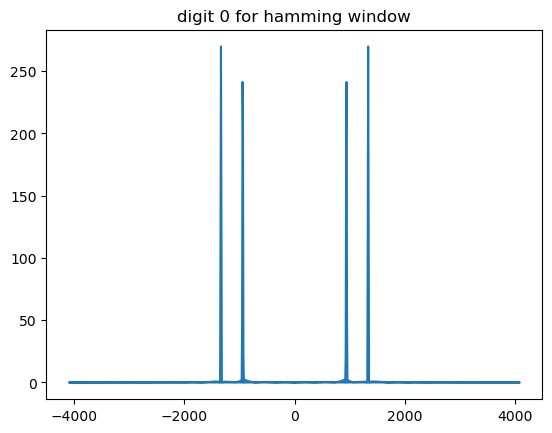

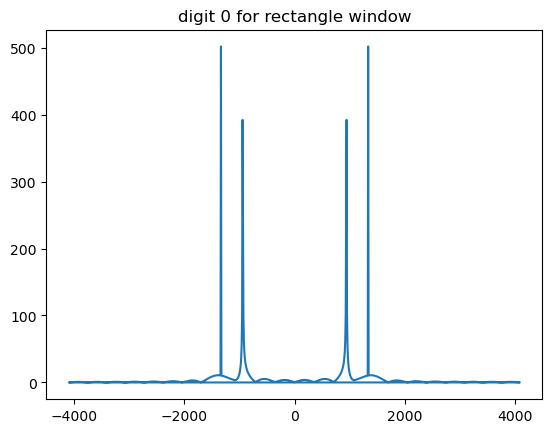

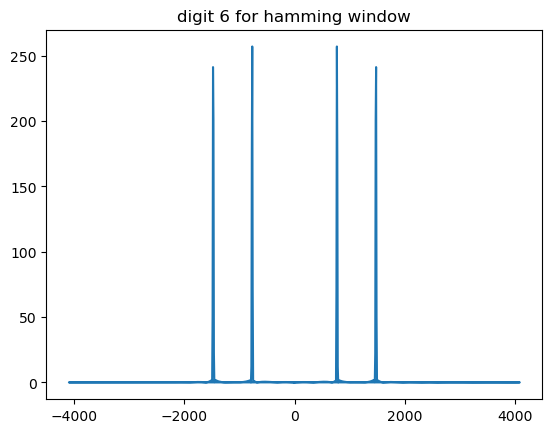

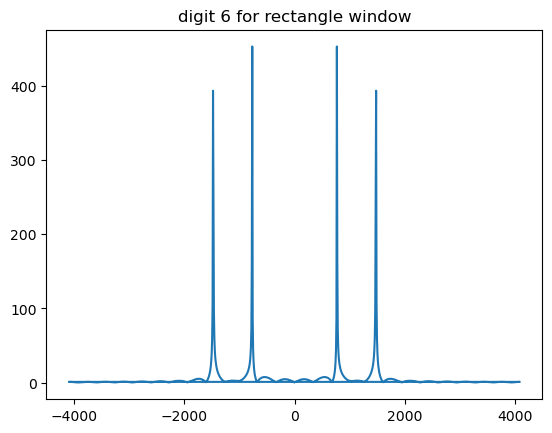

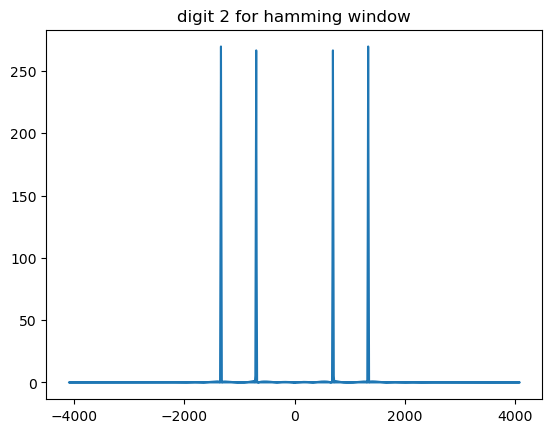

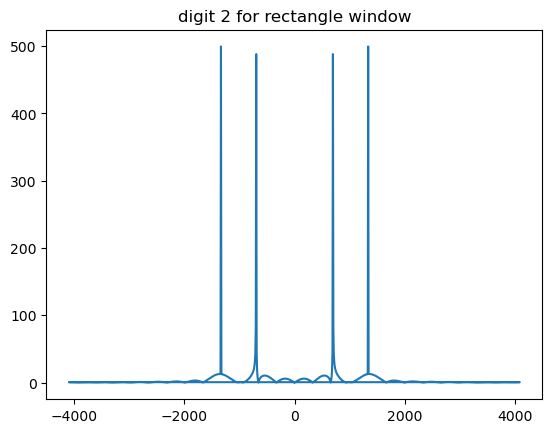

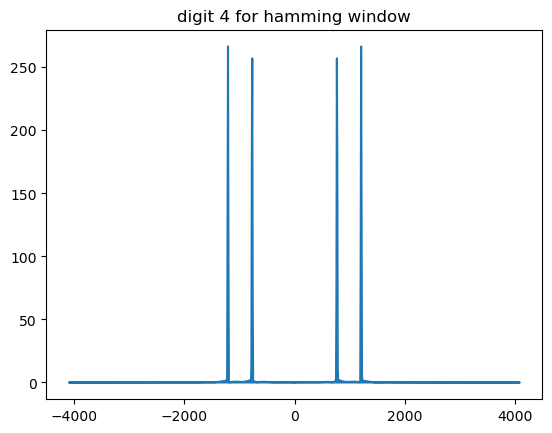

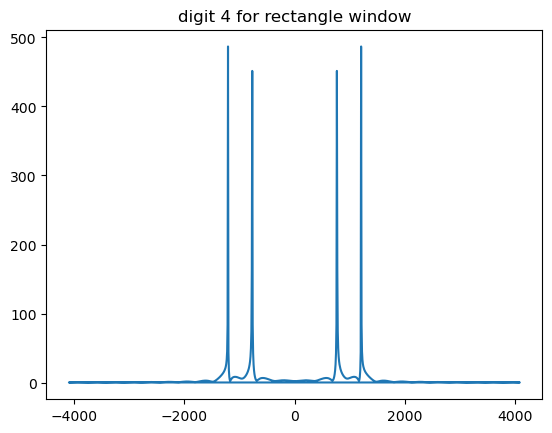

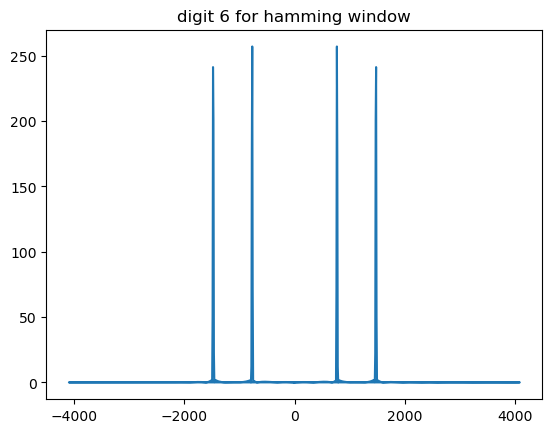

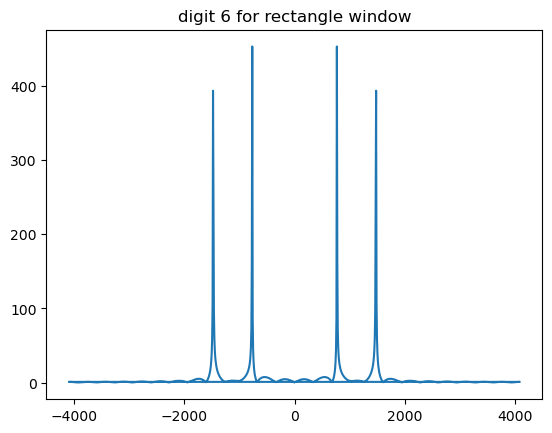

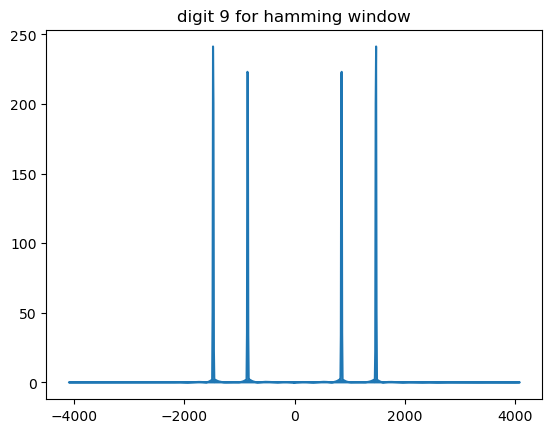

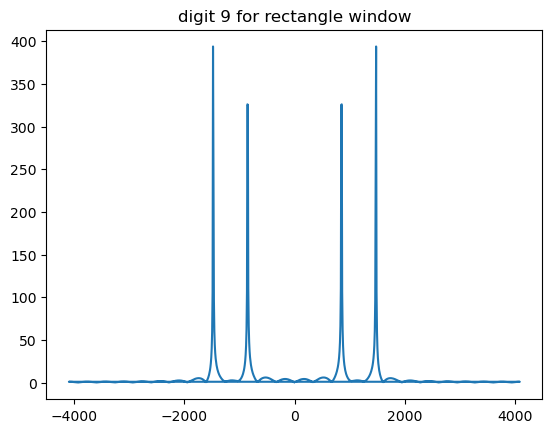

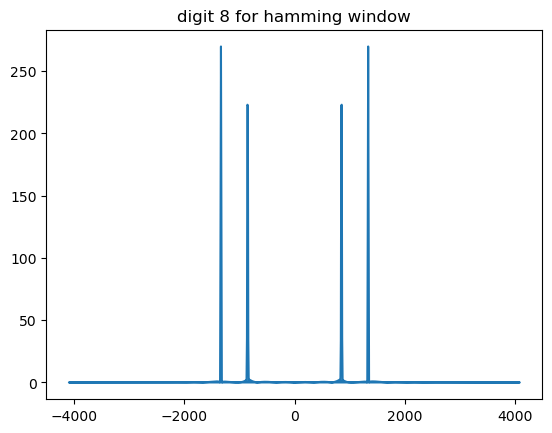

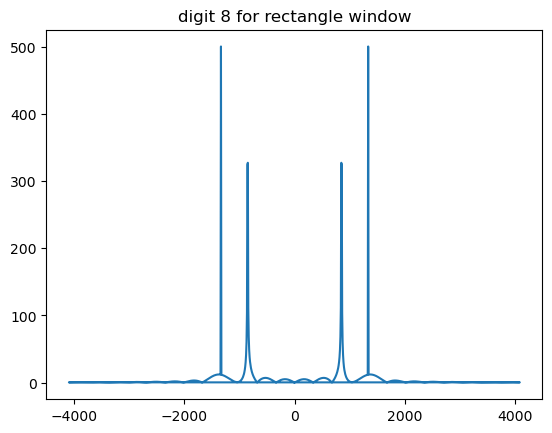

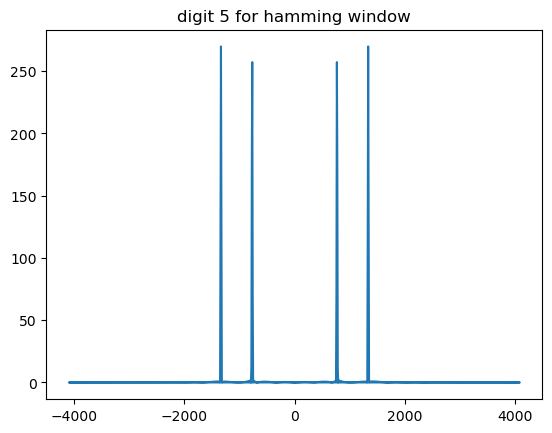

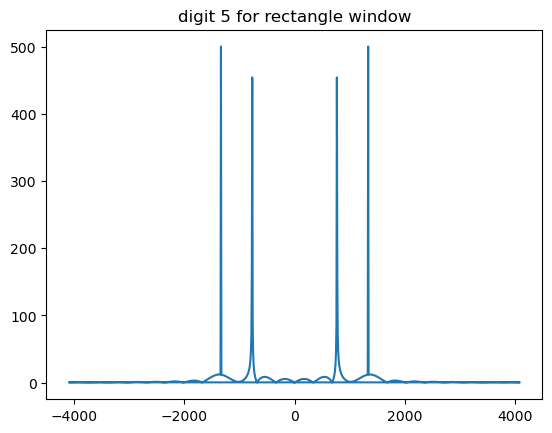

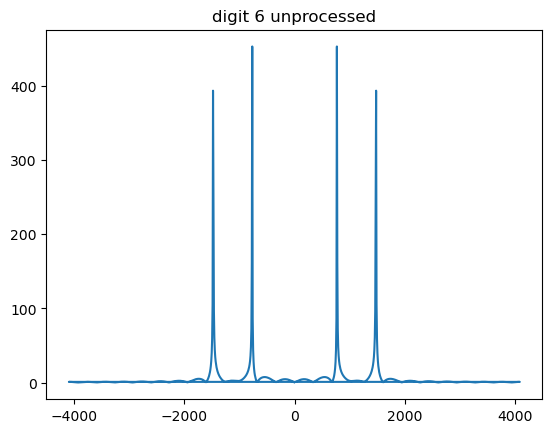

In [157]:
#1.4
#για το tone_sequence του προηγούμενου ερωτήματος
hamming_window = np.hamming(1000)
rectangular_window = np.ones(1000)

d_seq_h = []
d_seq_r = []
for c in range(0, len(AM1)): 
    start = c*1000+c*100 #παραβλέπουμε τα 100 μηδενικά ανάμεσα στους τόνους
    end = start + 1000
    t1 = tone_sequence[start:end] * hamming_window
    t2 = tone_sequence[start:end] * rectangular_window
    d_seq_h.append(t1)
    d_seq_r.append(t2)

D_seq_h = []
D_seq_r = []

for i in range(0, len(d_seq_h)): #DFTS 1024 σημείων
    D_seq_h.append(np.fft.fft(d_seq_h[i],1024))
    D_seq_r.append(np.fft.fft(d_seq_r[i],1024))

#plotting dfts for each digit in tone sequence and for each window, διαδοχικά
digits_ = [0, 6, 2, 4, 6, 9, 8, 5]
count = 0
for i in range(0, len(d_seq_h)):
    plt.figure(count)
    count += 1
    plt.plot(f, np.abs(D_seq_h[i]))
    plt.title(f"digit {digits_[i]} for hamming window")
    plt.figure(count)
    count += 1
    plt.plot(f, np.abs(D_seq_r[i]))
    plt.title(f"digit {digits_[i]} for rectangle window")

#σύγκριση με το ψηφίο 6 από πριν
plt.figure(count)
plt.title("digit 6 unprocessed")
plt.plot(f, np.abs(D6))

In [158]:
#1.5
#αυτά είναι για τα υπόλοιπα ερωτήματα
f_low = [] #row
f_high = [] #column
k_low = [] #row
k_high = [] #column
#αυτά για τα tones και χαμηλή και υψηλή συχνότητα
k_tones = []
f_tones = []
#καλύτερα DFT περισσότερων σημείων όπως φαίνεται στην αναφορά απλώς εμάς μας νοιάζει να βρίσκουμε τόνους
for i in range(0, len(d)):
    t1 = d[i] * hamming_window
    T1 = np.fft.fft(t1, 1024)
    T1 = T1[:512] #DFT symmetry
    k_peaks = np.argsort(np.abs(T1))[-2:] #επιστρέφει τα δύο μέγιστα όπου έχουμε τα δύο ημίτονα των tones
    k_peaks = np.sort(k_peaks) #χαμηλή συχνότητα πρ΄΄ωτα
    k_tones.append(k_peaks)
    f_tones.append(k_peaks/1024 * 8192)
    if i == 0 or i == 1 or i == 4 or i == 7: #αφού τα ψηφία 0,1,4,7 έχουν τα διαφορετικά row freqs
        k_low.append(k_peaks[0])
        f_low.append(k_peaks[0]/1024 * 8192) #fs = 8192Hz, N = 1024
        if i == 1:
            k_high.append(k_peaks[1]) #έχει το πρώτο column freq το ψηφίο 1
            f_high.append(k_peaks[1]/1024 * 8192)
    elif i == 2 or i == 3: #και τα 2,3 τα υπόλοιπα
        k_high.append(k_peaks[1])
        f_high.append(k_peaks[1]/1024 * 8192)

for idx, x in enumerate(k_tones):
    print("k for digit", idx, x) 
for idx, x in enumerate(f_tones):
    print("f for  digit", idx, x)

k for digit 0 [118 167]
k for digit 1 [ 87 151]
k for digit 2 [ 87 167]
k for digit 3 [ 87 185]
k for digit 4 [ 96 151]
k for digit 5 [ 96 167]
k for digit 6 [ 96 185]
k for digit 7 [107 151]
k for digit 8 [107 167]
k for digit 9 [107 185]
f for  digit 0 [ 944. 1336.]
f for  digit 1 [ 696. 1208.]
f for  digit 2 [ 696. 1336.]
f for  digit 3 [ 696. 1480.]
f for  digit 4 [ 768. 1208.]
f for  digit 5 [ 768. 1336.]
f for  digit 6 [ 768. 1480.]
f for  digit 7 [ 856. 1208.]
f for  digit 8 [ 856. 1336.]
f for  digit 9 [ 856. 1480.]


In [159]:
#1.6
def ttdecode(tone_sequence):
    vector = []
    start = 0 #παράθυρο 5 δειγμάτων
    end = 5
    energy = np.sum(tone_sequence[start:end] ** 2)
    #print(energy)
    while start < len(tone_sequence):
       while energy < 5: #από πολλές εκτελέσεις φάνηκε ότι η ενέργεια των σημάτων στα rect παράθυρα των 5 δειγμάτων                        
            start += 5   #είναι περίπου 5.5,6,7 επομένως βάζουμε κατώφλι 5
            end += 5
            energy = np.sum(tone_sequence[start:end] ** 2)
            #print(energy)
       end = start + 1000 #κάθε τόνος έχει 1000 δείγματα
       t1 = tone_sequence[start:end] * hamming_window #το 1000 παράθυρο
       T1 = np.fft.fft(t1,1024)
       T1 = T1[:512] #συμμετρία DFT
       k_peaks = np.argsort(np.abs(T1))[-2:]
       k_peaks = np.sort(k_peaks) #χαμηλή συχνότητα row και υψηλή συχνο΄τητα column
       v1 = min(k_low, key=lambda x: abs(x - k_peaks[0])) #επιστρέφει το πιο κοντινό μέσα στην λίστα των low freqs, row
       v2 = min(k_high, key=lambda x: abs(x - k_peaks[1])) #επιστρέφει το πιο κοντινό στη λίστα των high freqs, column
       i1 = k_low.index(v1)
       i2 = k_high.index(v2) 
       vector.append(digits[(i1,i2)])
       start = end #ξεκινάμε μετά τον τόνο που βρήκαμε
       end += 5
       energy = np.sum(tone_sequence[start:end] ** 2)
    return vector
digits = { #αντιστοίχιση των ψηφίων σε ζεύγη όπου τα indices των γραμμών freqs είναι σχηματικά 1,2,3,0 (εμείς
           #θεωρούμε γενικ΄α ότι το πρώτο ψηφίο είναι το 0, έτσι μπαίνουν και από το προηγούμενο for loop #1.5) και των στηλών 0,1,2
    (1, 0) : 1, (1, 1) : 2, (1,2): 3, (2,0): 4, (2,1): 5, (2,2) : 6,
    (3,0) : 7, (3,1) : 8, (3,2) : 9, (0, 1): 0
}
vector = ttdecode(tone_sequence) 
print("The AM tone sequence is:",vector)

The AM tone sequence is: [0, 6, 2, 4, 6, 9, 8, 5]


In [160]:
#1.7
easy = np.load("easy_sig.npy")
medium = np.load("medium_sig.npy")
hard = np.load("hard_sig.npy")

#print(len(easy))   8700
#print(len(medium)) 11300 διαφορετικού τύπου σήμα
#print(len(hard))   10750 διαφορετικού τύπου σήμα

#print("Easy sig energies")
vector1 = ttdecode(easy)
#print("Medium sig energies")
vector2 = ttdecode(medium)
#print("Hard sig energies")
vector3 = ttdecode(hard)

print("The easy sequence is:",vector1)
print("The medium sequence is:",vector2)
print("The hard sequence is:",vector3)

#if you want to listen to them, here you go, they are identical
#sf.write("easy.wav", easy/np.max(np.abs(easy)), 8192)
#sf.write("medium.wav", medium/np.max(np.abs(medium)), 8192)
#sf.write("hard.wav", hard/np.max(np.abs(hard)), 8192)
#def hearing(vector, i):
#    tone = vector[0]
#    start = 1000 * tone
#    end = start + 1000
#    t1 = np.concatenate([data[start:end], a])
#    tone_sequence = t1
#    for idx in range(1, len(vector)):
#       tone = vector[idx] 
#        start = 1000 * tone
#        end = start + 1000 
#        if idx != len(vector)-1:
#           t1 = np.concatenate([data[start:end], a]) 
#        else: 
#            t1 = data[start:end]
#        tone_sequence = np.concatenate([tone_sequence, t1])
#    sf.write(f'tone_sequence_{i}.wav', tone_sequence/np.max(np.abs(tone_sequence)), 8192)

#i = 0
#hearing(vector1,i)
#i += 1
#hearing(vector2, i)
#i += 1
#hearing(vector3, i)

The easy sequence is: [1, 1, 5, 7, 1, 4, 4, 9]
The medium sequence is: [6, 6, 0, 8, 8, 7, 7, 2, 3, 0]
The hard sequence is: [1, 1, 5, 8, 4, 5, 2, 9, 0, 4]
